# VGG16 Test with the already converted spectra.

In [44]:
# imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D, Activation, Flatten, BatchNormalization, MaxPool2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import shutil
import itertools
import random

In [34]:
def delete_all_files(folder_path):
    files = glob.glob(os.path.join(folder_path, '*'))
    for f in files:
        try:
            os.remove(f)
        except OSError as e:
            print(f"Error: {f} : {e.strerror}")

In [57]:
# data
n_train = 150
n_valid = 50
n_test = 50
n = n_train + n_valid + n_test

train_path = 'Data/cnn/train'
test_path = 'Data/cnn/test'
valid_path = 'Data/cnn/valid'

delete_all_files(train_path+'/corypha')
delete_all_files(train_path+'/borassus')
delete_all_files(test_path+'/corypha')
delete_all_files(test_path+'/borassus')
delete_all_files(valid_path+'/corypha')
delete_all_files(valid_path+'/borassus')

for i, img in enumerate(random.sample(glob.glob('Data/img/RGB/corypha/img*'), n)):
    if i < n_train: shutil.copy(img, train_path+'/corypha')
    elif i < n_train+n_valid: shutil.copy(img, valid_path+'/corypha')
    else: shutil.copy(img, test_path+'/corypha')

for i, img in enumerate(random.sample(glob.glob('Data/img/RGB/borassus/img*'), n)):
    if i < n_train: shutil.copy(img, train_path+'/borassus')
    elif i < n_train+n_valid: shutil.copy(img, valid_path+'/borassus')
    else: shutil.copy(img, test_path+'/borassus')


In [58]:
# rescale images directly to 224,224
for i in glob.glob('Data/cnn/*/*/*.png'):
    img = Image.open(i).resize((224,224), Image.Resampling.BOX)
    img.save(i)

In [59]:
# batches
train_batch = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(train_path, target_size=(224, 224), classes=['corypha','borassus'], batch_size=10)
valid_batch = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(valid_path, target_size=(224, 224), classes=['corypha','borassus'], batch_size=10)
test_batch = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(test_path, target_size=(224, 224), classes=['corypha','borassus'], batch_size=10)


Found 300 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [60]:
imgs, labels = next(train_batch)

In [61]:
def plotImages(images_arr):
    fig, axes = plt.subplots(1,10,figsize=(20,20))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..125.32].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-122.68..128.32].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..130.32].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..129.32].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..130.32].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-122.68..130.32].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..130.32].
Clipping input data to the 

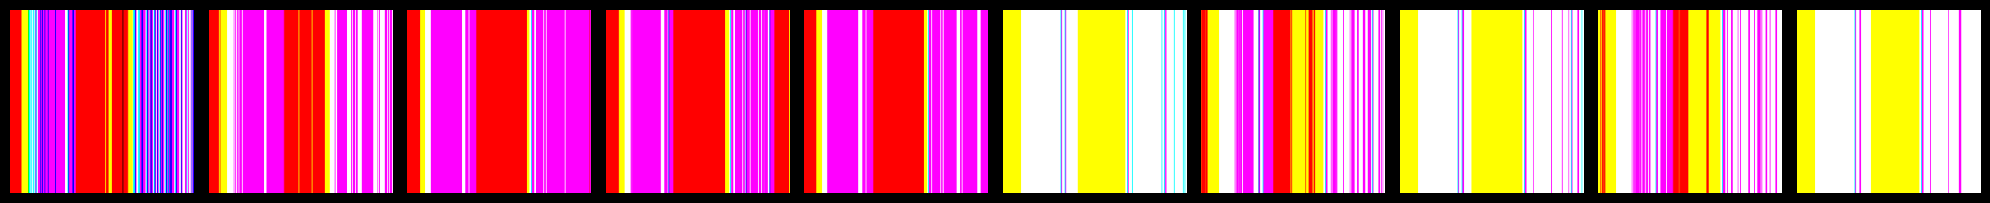

[[1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]


In [62]:
plotImages(imgs)
print(labels)

In [14]:
model = Sequential([
    Conv2D(filters = 32, kernel_size = (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    MaxPool2D(pool_size = (2,2), strides = 2),

    Conv2D(filters = 64, kernel_size = (3,3), activation='relu', padding='same'),
    MaxPool2D(pool_size = (2,2), strides = 2),

    Flatten(),
    Dense(units = 2, activation='softmax'),
])

In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 56, 56, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 200704)            0         
                                                                 
 dense (Dense)               (None, 2)                 4

In [16]:
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [18]:
model.fit(x=train_batch, validation_data=valid_batch, epochs=15, verbose=2)

Epoch 1/15
30/30 - 3s - loss: 0.2496 - accuracy: 0.9467 - val_loss: 1.3563 - val_accuracy: 0.8200 - 3s/epoch - 88ms/step
Epoch 2/15
30/30 - 3s - loss: 0.2707 - accuracy: 0.9267 - val_loss: 2.0731 - val_accuracy: 0.7900 - 3s/epoch - 92ms/step
Epoch 3/15
30/30 - 3s - loss: 0.1739 - accuracy: 0.9600 - val_loss: 2.0808 - val_accuracy: 0.7400 - 3s/epoch - 103ms/step
Epoch 4/15
30/30 - 3s - loss: 0.0720 - accuracy: 0.9800 - val_loss: 1.8168 - val_accuracy: 0.7700 - 3s/epoch - 99ms/step
Epoch 5/15
30/30 - 3s - loss: 0.0405 - accuracy: 0.9900 - val_loss: 1.3253 - val_accuracy: 0.8100 - 3s/epoch - 101ms/step
Epoch 6/15
30/30 - 3s - loss: 0.0129 - accuracy: 0.9967 - val_loss: 1.3214 - val_accuracy: 0.8100 - 3s/epoch - 107ms/step
Epoch 7/15
30/30 - 3s - loss: 0.0057 - accuracy: 1.0000 - val_loss: 1.2910 - val_accuracy: 0.8100 - 3s/epoch - 114ms/step
Epoch 8/15
30/30 - 3s - loss: 0.0179 - accuracy: 0.9967 - val_loss: 1.3229 - val_accuracy: 0.8000 - 3s/epoch - 112ms/step
Epoch 9/15
30/30 - 3s - los

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..97.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-112.779..81.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-116.68..83.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-111.779..96.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-118.68..150.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-106.779..129.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-112.779..99.061].
Clipping input data t

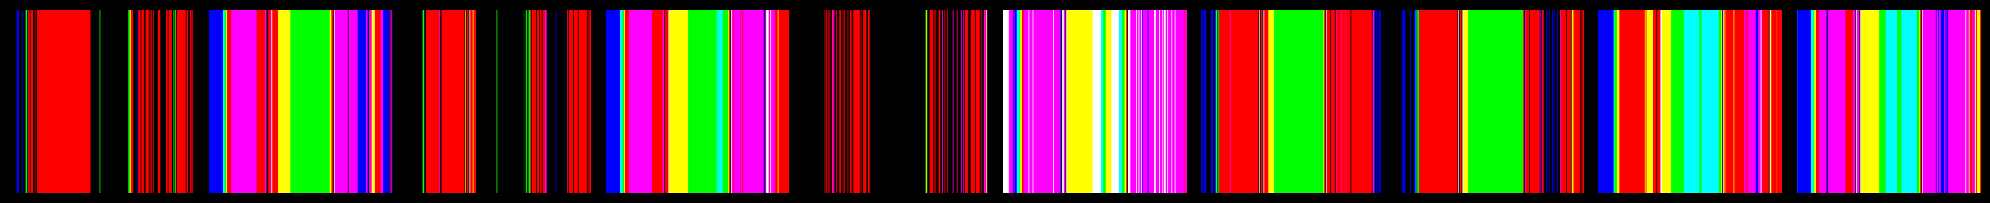

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [19]:
test_imgs, test_labels = next(test_batch)
plotImages(test_imgs)
print(test_labels)
print(test_batch.classes)

In [20]:
pred = model.predict(x=test_batch, verbose=0)

In [21]:
np.round(pred)

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.

In [22]:
cm = confusion_matrix(y_true=test_batch.classes, y_pred=np.argmax(pred, axis=-1))

In [23]:
def plot_confusion_matrix(cm, classes, normalize=False, title = 'Confusion matrix', cmap = plt.cm.Reds):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [24]:
test_batch.class_indices

{'corypha': 0, 'borassus': 1}

Confusion matrix, without normalization
[[29 21]
 [27 23]]


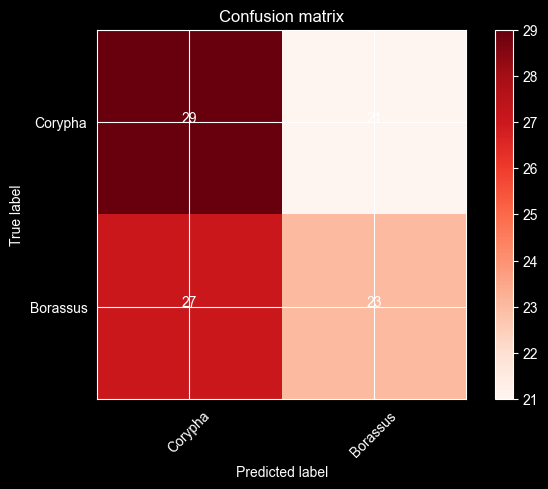

In [25]:
cm_plot_labels = ['Corypha', 'Borassus']
plot_confusion_matrix(cm,cm_plot_labels, title='Confusion matrix')

# FINE TUNED Model

In [26]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
vgg16_model = tf.keras.applications.vgg16.VGG16()

In [63]:
vgg16_model_custom = Sequential()
for layer in vgg16_model.layers[:-1]:
    vgg16_model_custom.add(layer)

In [64]:
for layer in vgg16_model_custom.layers:
    layer.trainable = False

In [65]:
vgg16_model_custom.add(Dense(units=2, activation='softmax'))

In [66]:
vgg16_model_custom.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [67]:
vgg16_model_custom.fit(x=train_batch, validation_data=valid_batch, epochs=10, verbose=2)

Epoch 1/10
30/30 - 51s - loss: 0.7765 - accuracy: 0.5000 - val_loss: 0.7182 - val_accuracy: 0.4900 - 51s/epoch - 2s/step
Epoch 2/10
30/30 - 46s - loss: 0.6523 - accuracy: 0.6200 - val_loss: 0.6845 - val_accuracy: 0.5800 - 46s/epoch - 2s/step
Epoch 3/10
30/30 - 45s - loss: 0.6171 - accuracy: 0.6900 - val_loss: 0.6964 - val_accuracy: 0.6200 - 45s/epoch - 2s/step
Epoch 4/10
30/30 - 41s - loss: 0.6034 - accuracy: 0.7033 - val_loss: 0.7157 - val_accuracy: 0.5900 - 41s/epoch - 1s/step
Epoch 5/10
30/30 - 40s - loss: 0.5866 - accuracy: 0.7067 - val_loss: 0.6945 - val_accuracy: 0.6100 - 40s/epoch - 1s/step
Epoch 6/10
30/30 - 39s - loss: 0.5723 - accuracy: 0.7233 - val_loss: 0.7129 - val_accuracy: 0.6200 - 39s/epoch - 1s/step
Epoch 7/10
30/30 - 39s - loss: 0.5694 - accuracy: 0.7500 - val_loss: 0.6805 - val_accuracy: 0.6400 - 39s/epoch - 1s/step
Epoch 8/10
30/30 - 39s - loss: 0.5710 - accuracy: 0.7400 - val_loss: 0.6788 - val_accuracy: 0.6200 - 39s/epoch - 1s/step
Epoch 9/10
30/30 - 39s - loss: 0

Confusion matrix, without normalization
[[26 24]
 [23 27]]


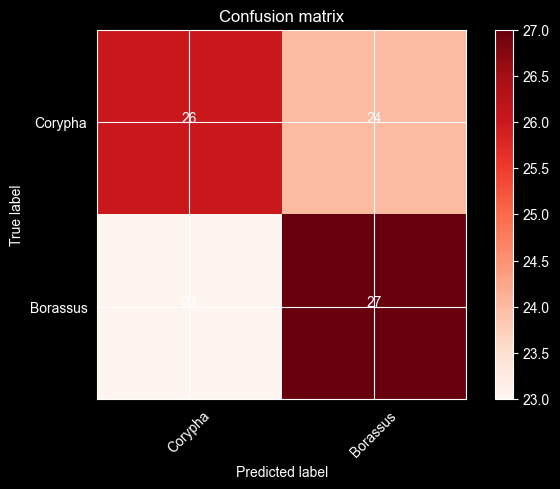

In [68]:
pred_vgg = vgg16_model_custom.predict(x=test_batch, verbose=0)
cm = confusion_matrix(y_true=test_batch.classes, y_pred=np.argmax(pred_vgg, axis=-1))
cm_plot_labels = ['Corypha', 'Borassus']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion matrix')